# Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/data science/Dataset/weatherHistory.csv")

# EDA

In [ ]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51,Partly cloudy throughout the day.




Displaying the first five rows of the dataset.

In [ ]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31,16.1000,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20,15.5526,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30,16.1000,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20,16.1000,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39,15.5204,1016.16,Partly cloudy starting in the morning.




Displaying the last five rows of the dataset.

In [ ]:
df.shape

(96453, 11)

Rows:-96453,
column:-11

In [ ]:
df.isna().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0


Checking for missing values in the dataset.

In [ ]:
# Fill missing values
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

Filling missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               96453 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  int64  
 8   Visibility (km)           96453 non-null  float64
 9   Pressure (millibars)      96453 non-null  float64
 10  Daily Summary             96453 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 8.1+ MB


Displaying data types and non-null values of each column.

In [ ]:
df.describe()


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


Displaying descriptive statistics of numerical features.

In [ ]:
df.nunique()

,0
Formatted Date,96429
Summary,27
Precip Type,2
Temperature (C),7574
Apparent Temperature (C),8984
Humidity,90
Wind Speed (km/h),2484
Wind Bearing (degrees),360
Visibility (km),949
Pressure (millibars),4979


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 24


Checking for duplicate records in the dataset.

In [ ]:
df = df.drop_duplicates()

Remove duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

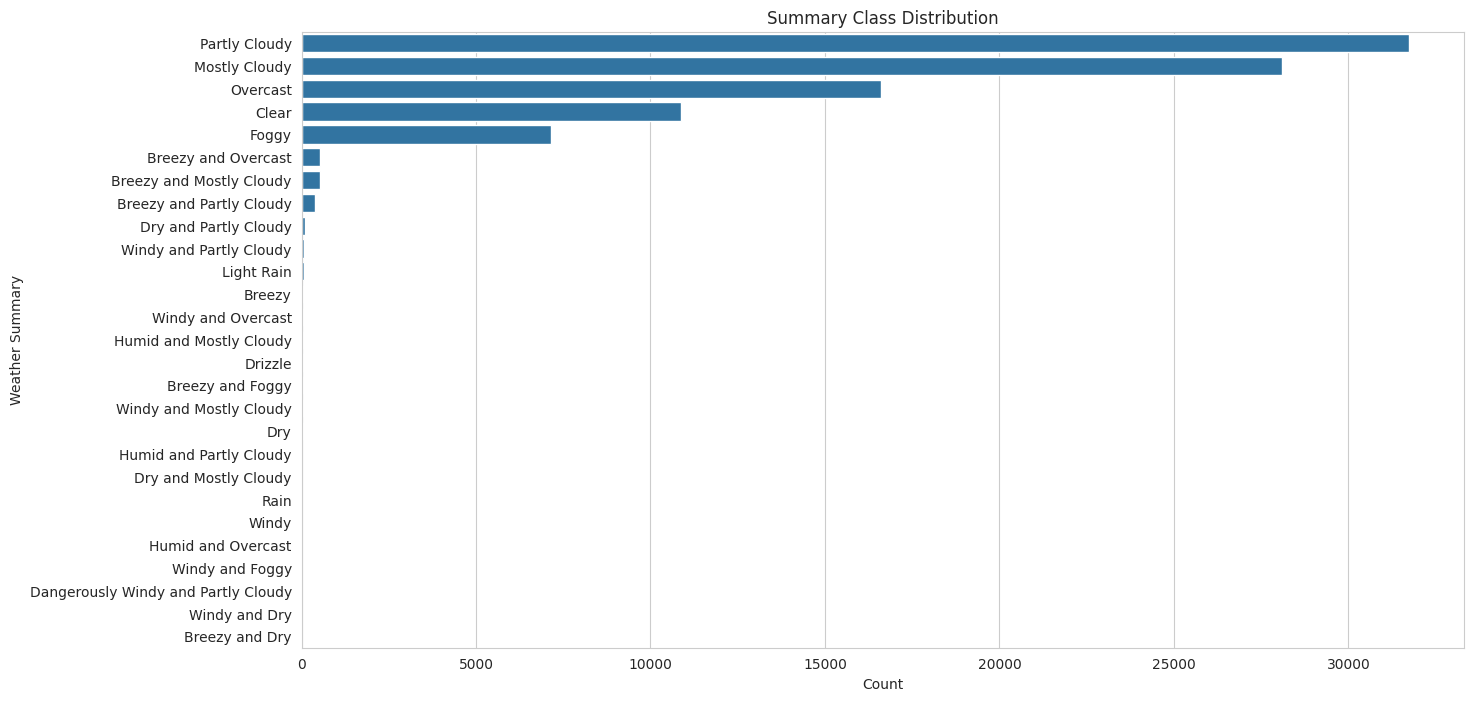

In [ ]:
plt.figure(figsize=(15,8))
sns.countplot(y='Summary',data=df,order=df['Summary'].value_counts().index)
plt.title('Summary Class Distribution')
plt.xlabel('Count')
plt.ylabel('Weather Summary')
plt.show()

The Summary column contains highly imbalanced classes. A few weather conditions account for most observations, while many classes have very low frequencies. To address this issue, similar weather summaries were grouped into broader weather categories for better model performance.

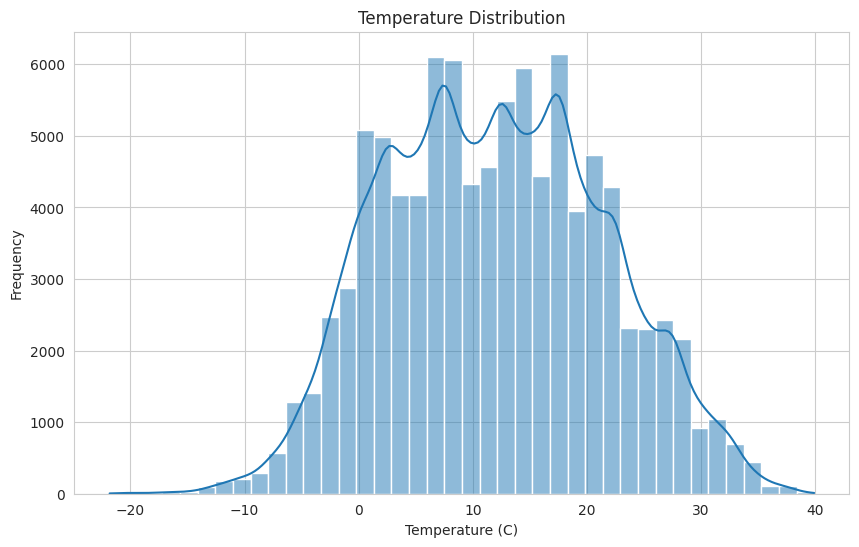

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Temperature (C)'],bins=40,kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.show()

Most temperature values are concentrated between 0°C and 25°C, while extreme temperatures occur less frequently.

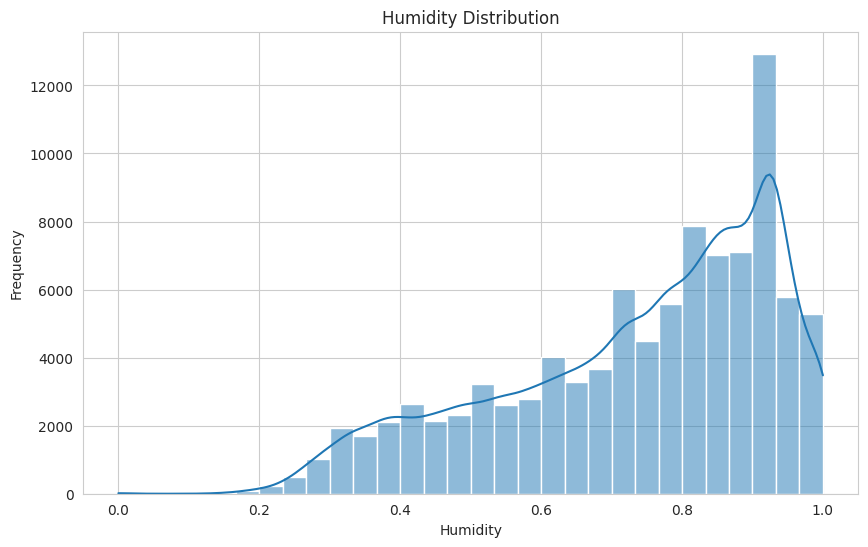

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Humidity'],bins=30,kde=True)
plt.title('Humidity Distribution')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.show()

Most humidity values are concentrated at higher levels, indicating that the dataset contains predominantly humid weather conditions.

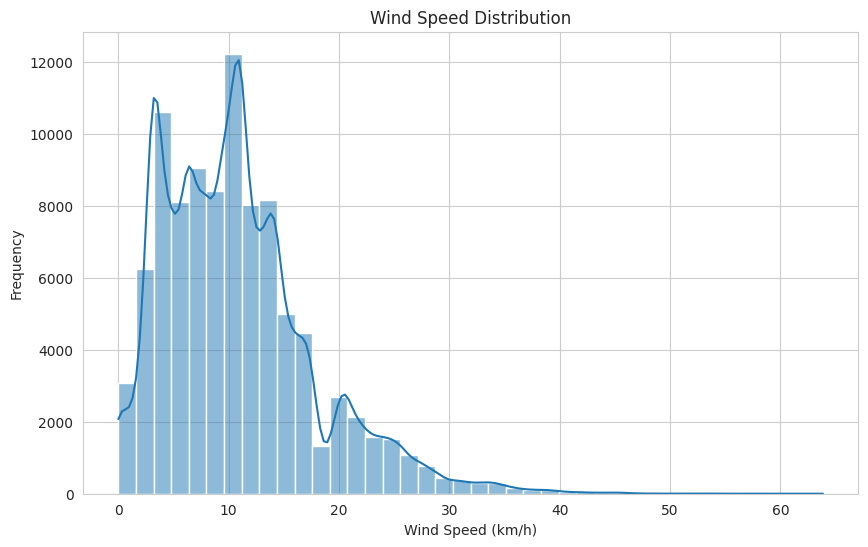

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Wind Speed (km/h)'],bins=40,kde=True)
plt.title('Wind Speed Distribution')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

Most wind speed values are concentrated at lower to moderate levels, while very high wind speeds occur less frequently.

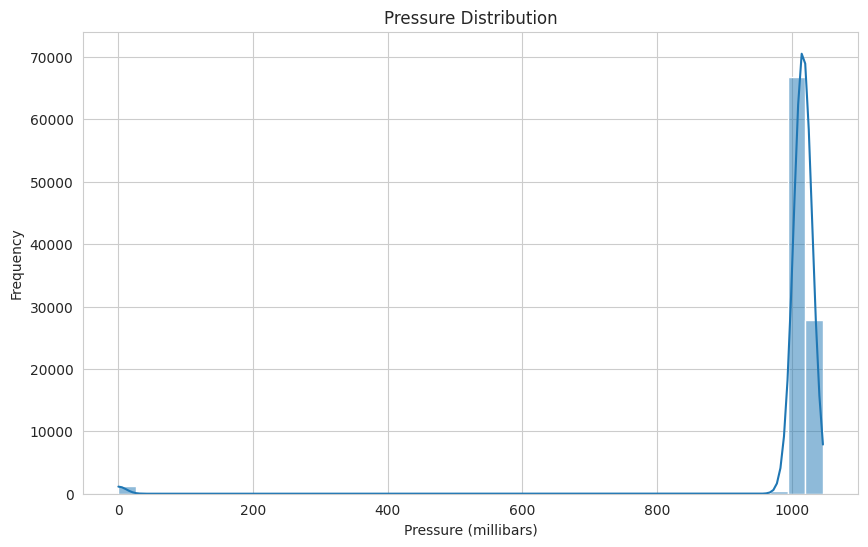

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Pressure (millibars)'],bins=40,kde=True)
plt.title('Pressure Distribution')
plt.xlabel('Pressure (millibars)')
plt.ylabel('Frequency')
plt.show()

Most pressure values are concentrated around 1000 millibars, indicating stable atmospheric pressure conditions in the dataset.

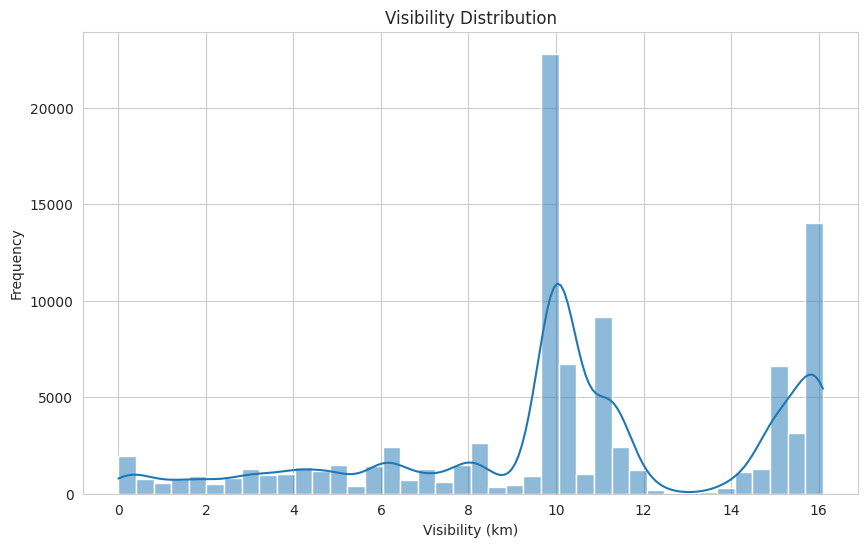

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Visibility (km)'],bins=40,kde=True)
plt.title('Visibility Distribution')
plt.xlabel('Visibility (km)')
plt.ylabel('Frequency')
plt.show()

Most visibility values are concentrated at higher levels, indicating that clear visibility conditions are common in the dataset.

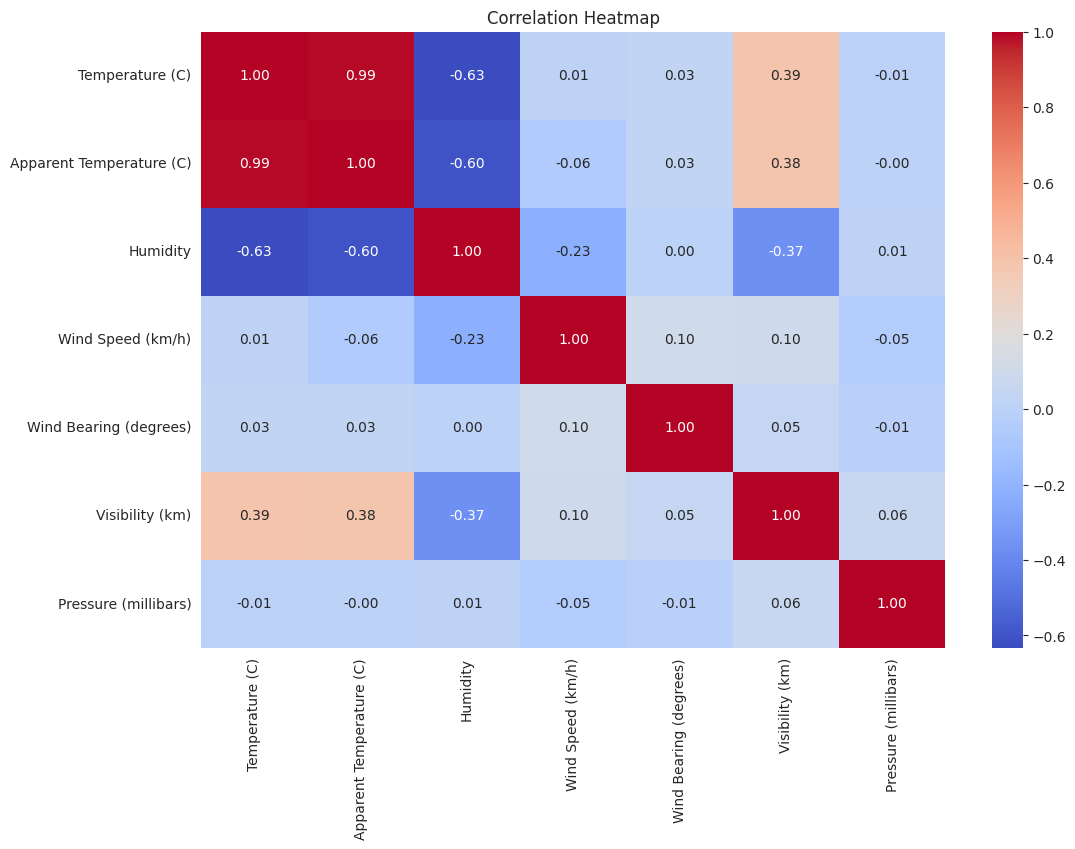

In [ ]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Temperature and Apparent Temperature show a very strong positive correlation, while Humidity has a moderate negative correlation with Temperature. Most other features exhibit weak correlations, indicating that they provide unique information for weather classification.

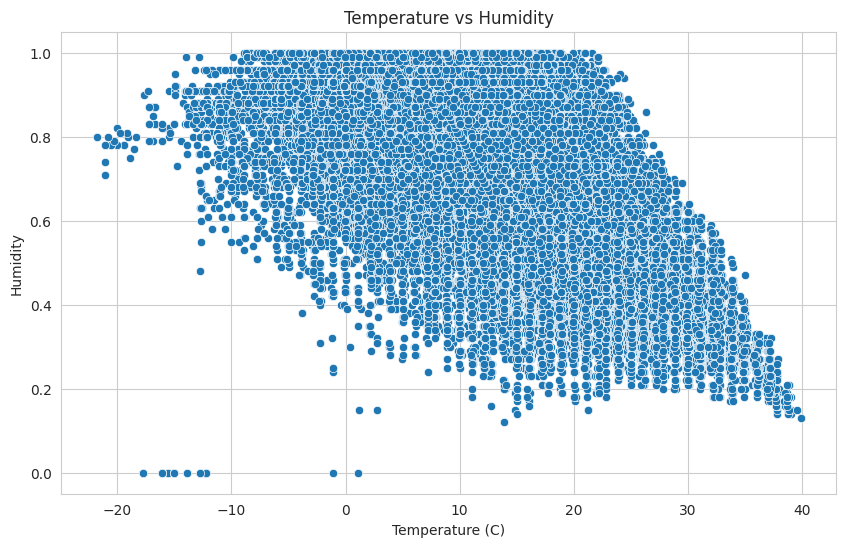

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Temperature (C)',y='Humidity',data=df)
plt.title('Temperature vs Humidity')
plt.show()

The scatter plot shows a negative relationship between temperature and humidity, indicating that humidity generally decreases as temperature increases.

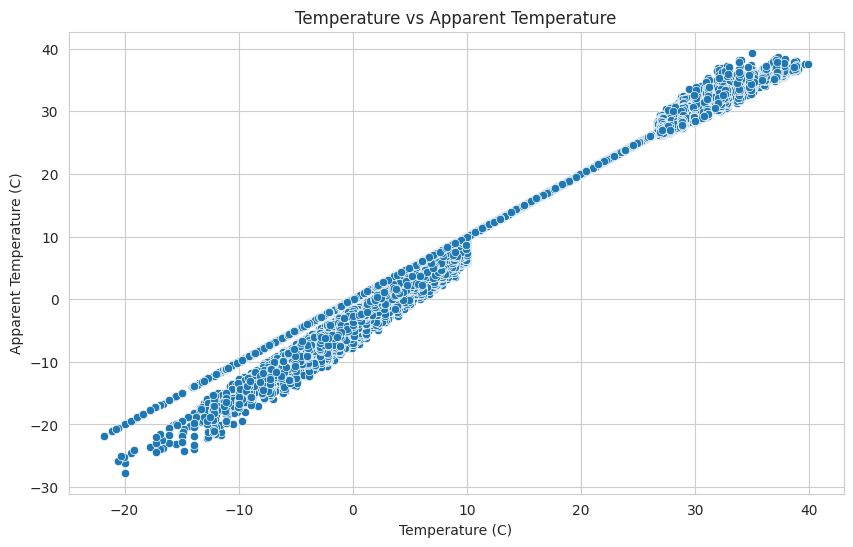

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Temperature (C)',y='Apparent Temperature (C)',data=df)
plt.title('Temperature vs Apparent Temperature')
plt.show()

The scatter plot shows a strong positive relationship between temperature and apparent temperature, indicating that both variables increase together.

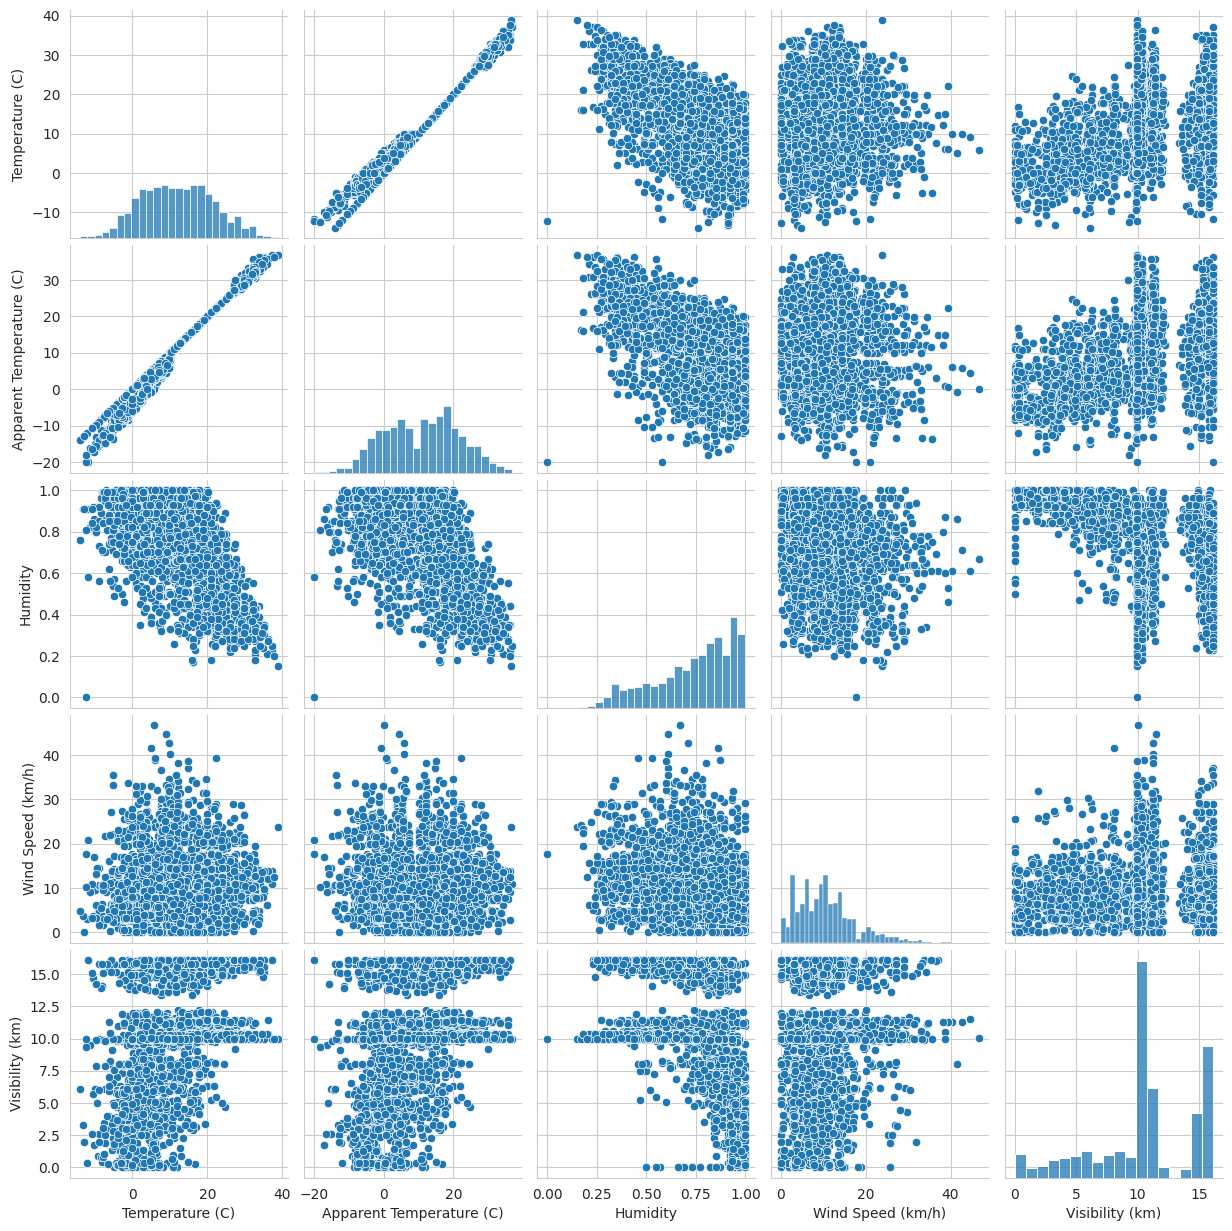

In [ ]:
sample_df = df.sample(n=3000,random_state=42)
features = ['Temperature (C)','Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Visibility (km)']
sns.pairplot(sample_df[features])
plt.show()

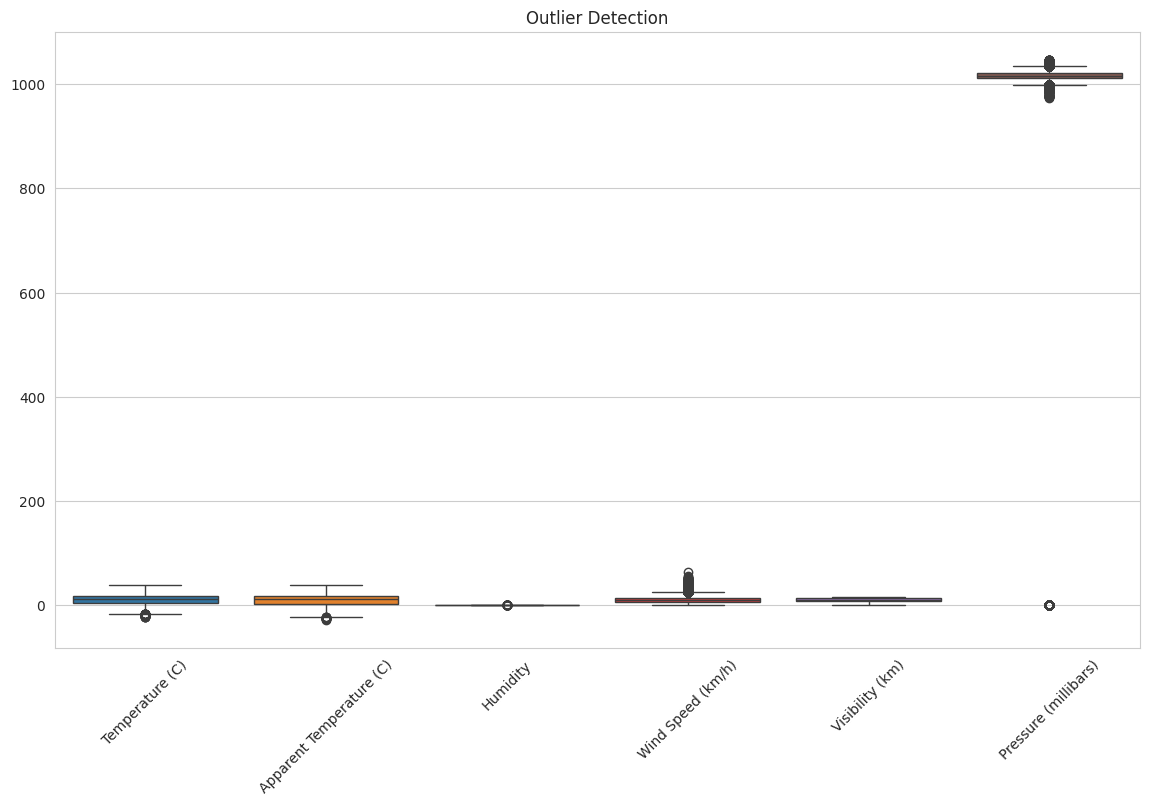

In [ ]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df[['Temperature (C)','Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Visibility (km)','Pressure (millibars)']])
plt.xticks(rotation=45)
plt.title('Outlier Detection')
plt.show()

The boxplots indicate the presence of outliers in several numerical features, particularly Wind Speed and Pressure. These extreme values may represent unusual weather conditions and should be considered during model development.

In [ ]:
df['Summary'].value_counts()

,count
Summary,
Partly Cloudy,31726
Mostly Cloudy,28094
Overcast,16597
Clear,10873
Foggy,7148
Breezy and Overcast,528
Breezy and Mostly Cloudy,516
Breezy and Partly Cloudy,386
Dry and Partly Cloudy,86


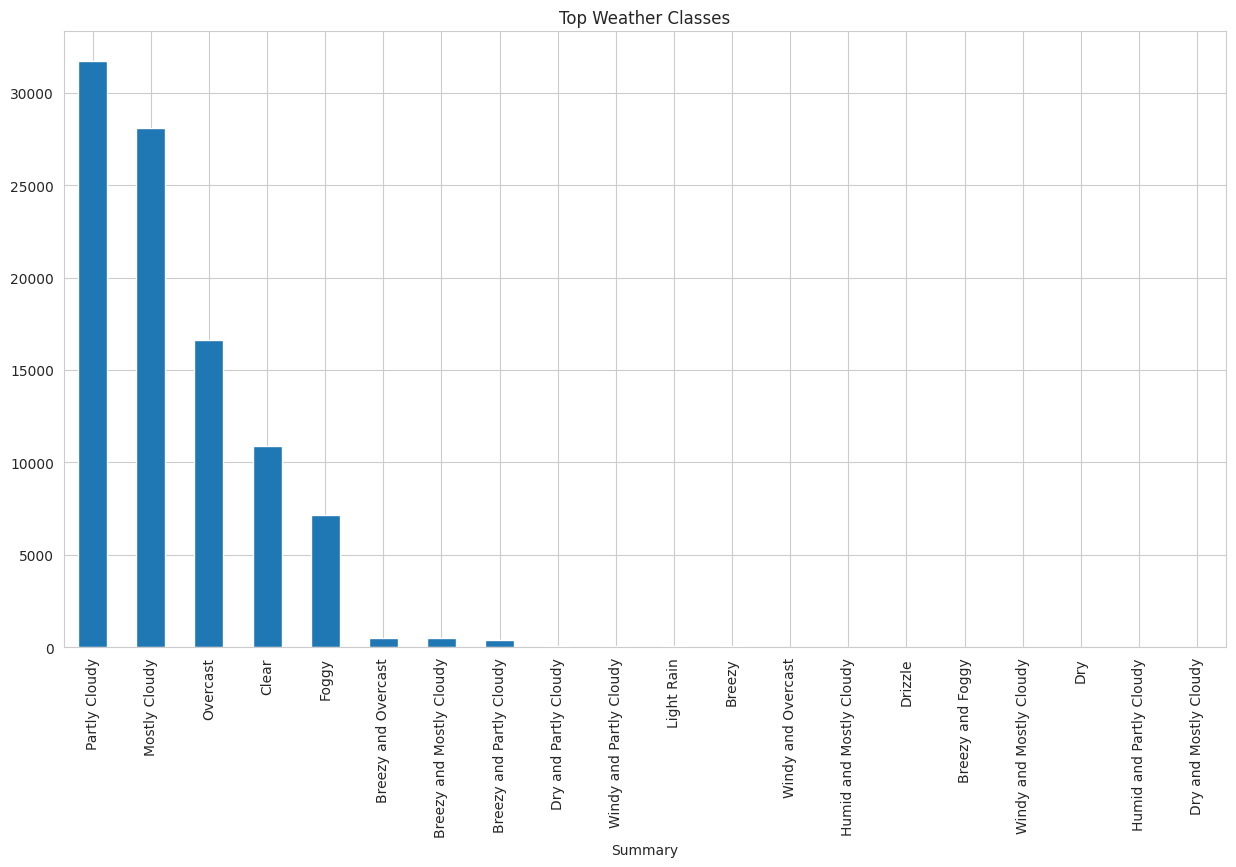

In [ ]:
plt.figure(figsize=(15,8))
df['Summary'].value_counts().head(20).plot(kind='bar')
plt.title("Top Weather Classes")
plt.show()

The chart shows that Partly Cloudy, Mostly Cloudy, Overcast, Clear, and Foggy are the most frequent weather classes, while many other classes have very few observations. This indicates a significant class imbalance in the dataset.

# Data preprocessing

In [ ]:
# Fill missing values
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

In [ ]:
# Convert datetime
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'],utc=True)

In [ ]:
# Create time features
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day'] = df['Formatted Date'].dt.day
df['Hour'] = df['Formatted Date'].dt.hour

In [ ]:
df['Temp_Diff'] = (df['Apparent Temperature (C)'] - df['Temperature (C)'])
df['Humidity_Temp'] = (df['Humidity'] * df['Temperature (C)'])
df['Wind_Visibility'] = (df['Wind Speed (km/h)'] * df['Visibility (km)'])

In [ ]:
# Drop unwanted columns
df.drop('Formatted Date',axis=1,inplace=True)

In [ ]:
# Feature Selection

# Encode Precip Type
precip_encoder = LabelEncoder()
df['Precip Type'] = precip_encoder.fit_transform(df['Precip Type'])

summary_encoder=LabelEncoder()
df['Summary'] = summary_encoder.fit_transform(df['Summary'])

# Target Encoding
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['Daily Summary'])

# Features
x= df.drop(['Daily Summary'],axis=1)

# Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model selection

1.   Logistic regression: Chosen as a simple and effective baseline classification model.
2.   SVM: Chosen for its ability to find optimal decision boundaries.
3.   Random forest: Chosen for handling complex patterns and reducing overfitting.
4.   XGBoost: Chosen for its high accuracy and strong predictive performance.

#logistic regression before grouping

In [ ]:
lg=LogisticRegression(max_iter=2000,random_state=42)

In [ ]:
lg.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
y_pred_lg=lg.predict(x_test_scaled)

In [ ]:
report = classification_report(y_test, y_pred_lg, output_dict=True)

print("Accuracy           :", report["accuracy"]*100)
print(" ")
print("Macro Precision    :", report["macro avg"]["precision"]*100)
print(" ")
print("Macro Recall       :", report["macro avg"]["recall"]*100)
print(" ")
print("Macro F1-score     :", report["macro avg"]["f1-score"]*100)
print(" ")
print("Weighted Precision :", report["weighted avg"]["precision"]*100)
print(" ")
print("Weighted Recall    :", report["weighted avg"]["recall"]*100)
print(" ")
print("Weighted F1-score  :", report["weighted avg"]["f1-score"]*100)
print(" ")

Accuracy           : 27.138857202115524
 
Macro Precision    : 20.190477238976094
 
Macro Recall       : 15.441653812557234
 
Macro F1-score     : 15.762764226722256
 
Weighted Precision : 18.717594957672382
 
Weighted Recall    : 27.138857202115524
 
Weighted F1-score  : 18.774813306368593
 


# SVM before grouping

In [ ]:
svm = LinearSVC(C=1.0,random_state=42,max_iter=5000)

In [ ]:
svm.fit(x_train_scaled,y_train)

LinearSVC(max_iter=5000, random_state=42)

In [ ]:
y_pred_svm = svm.predict(x_test_scaled)

In [ ]:
report = classification_report(y_test, y_pred_svm, output_dict=True)

print("Accuracy           :", report["accuracy"]*100)
print(" ")
print("Macro Precision    :", report["macro avg"]["precision"]*100)
print(" ")
print("Macro Recall       :", report["macro avg"]["recall"]*100)
print(" ")
print("Macro F1-score     :", report["macro avg"]["f1-score"]*100)
print(" ")
print("Weighted Precision :", report["weighted avg"]["precision"]*100)
print(" ")
print("Weighted Recall    :", report["weighted avg"]["recall"]*100)
print(" ")
print("Weighted F1-score  :", report["weighted avg"]["f1-score"]*100)
print(" ")

Accuracy           : 25.474437415741992
 
Macro Precision    : 13.666168024771592
 
Macro Recall       : 11.540663126298542
 
Macro F1-score     : 10.819090817597518
 
Weighted Precision : 13.843912908937945
 
Weighted Recall    : 25.474437415741992
 
Weighted F1-score  : 15.021405861545315
 


# random forest before grouping

In [ ]:
rf = RandomForestClassifier(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)

In [ ]:
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [ ]:
report = classification_report(y_test, y_pred_rf, output_dict=True)

print("Accuracy           :", report["accuracy"]*100)
print(" ")
print("Macro Precision    :", report["macro avg"]["precision"]*100)
print(" ")
print("Macro Recall       :", report["macro avg"]["recall"]*100)
print(" ")
print("Macro F1-score     :", report["macro avg"]["f1-score"]*100)
print(" ")
print("Weighted Precision :", report["weighted avg"]["precision"]*100)
print(" ")
print("Weighted Recall    :", report["weighted avg"]["recall"]*100)
print(" ")
print("Weighted F1-score  :", report["weighted avg"]["f1-score"]*100)
print(" ")

Accuracy           : 59.696152649590374
 
Macro Precision    : 80.98565981529131
 
Macro Recall       : 44.86013307705274
 
Macro F1-score     : 54.191316208588226
 
Weighted Precision : 66.39859346362161
 
Weighted Recall    : 59.696152649590374
 
Weighted F1-score  : 57.9891632931479
 


# XGBoost before grouping

In [ ]:
xgb = XGBClassifier(objective='multi:softmax',num_class=len(class_names),n_estimators=200,max_depth=8,learning_rate=0.1,random_state=42,eval_metric='mlogloss')

In [ ]:
xgb.fit(x_train,y_train)
y_pred_xgb = xgb.predict(x_test)

In [ ]:
report = classification_report(y_test, y_pred_xgb, output_dict=True)

print("Accuracy           :", report["accuracy"]*100)
print(" ")
print("Macro Precision    :", report["macro avg"]["precision"]*100)
print(" ")
print("Macro Recall       :", report["macro avg"]["recall"]*100)
print(" ")
print("Macro F1-score     :", report["macro avg"]["f1-score"]*100)
print(" ")
print("Weighted Precision :", report["weighted avg"]["precision"]*100)
print(" ")
print("Weighted Recall    :", report["weighted avg"]["recall"]*100)
print(" ")
print("Weighted F1-score  :", report["weighted avg"]["f1-score"]*100)
print(" ")

Accuracy           : 81.89360157627294
 
Macro Precision    : 92.4706558600654
 
Macro Recall       : 85.1586765793854
 
Macro F1-score     : 87.98318050938371
 
Weighted Precision : 82.78916797435197
 
Weighted Recall    : 81.89360157627294
 
Weighted F1-score  : 81.88956762582131
 


# Weather Category Creation

In [ ]:
def map_weather(text):
    text = str(text).lower()

    if 'clear' in text:
        return 'Clear'

    elif 'fog' in text:
        return 'Foggy'

    elif 'rain' in text or 'drizzle' in text:
        return 'Rain'

    elif ('cloudy' in text or
          'overcast' in text):
        return 'Cloudy'

    elif ('windy' in text or
          'breezy' in text):
        return 'Windy'

    else:
        return 'Other'

In [ ]:
df['Weather_Category'] = df['Daily Summary'].apply(map_weather)



To reduce class imbalance and simplify the classification problem, similar weather descriptions from the Daily Summary column were grouped into broader weather categories. This preprocessing step helps improve model generalization and makes the prediction results easier to interpret.

# weather category analysis

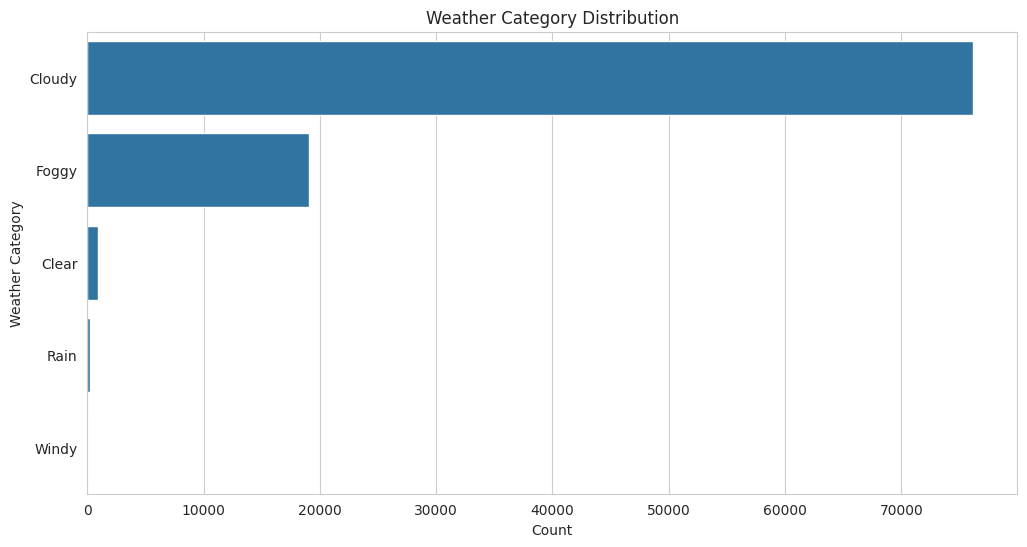

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y='Weather_Category',data=df,order=df['Weather_Category'].value_counts().index)
plt.title('Weather Category Distribution')
plt.xlabel('Count')
plt.ylabel('Weather Category')
plt.show()

The Cloudy category contains the majority of observations, while other categories have significantly fewer records, indicating class imbalance.

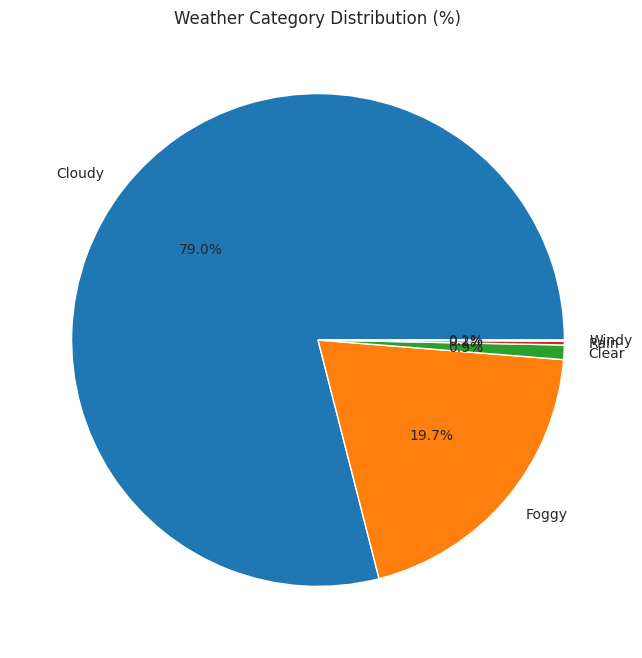

In [ ]:
plt.figure(figsize=(8,8))
df['Weather_Category'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Weather Category Distribution (%)')
plt.show()

The pie chart shows that the Cloudy category accounts for the majority of observations (79%), followed by Foggy (19.7%). The remaining categories contribute only a very small percentage of the dataset, indicating a significant class imbalance.

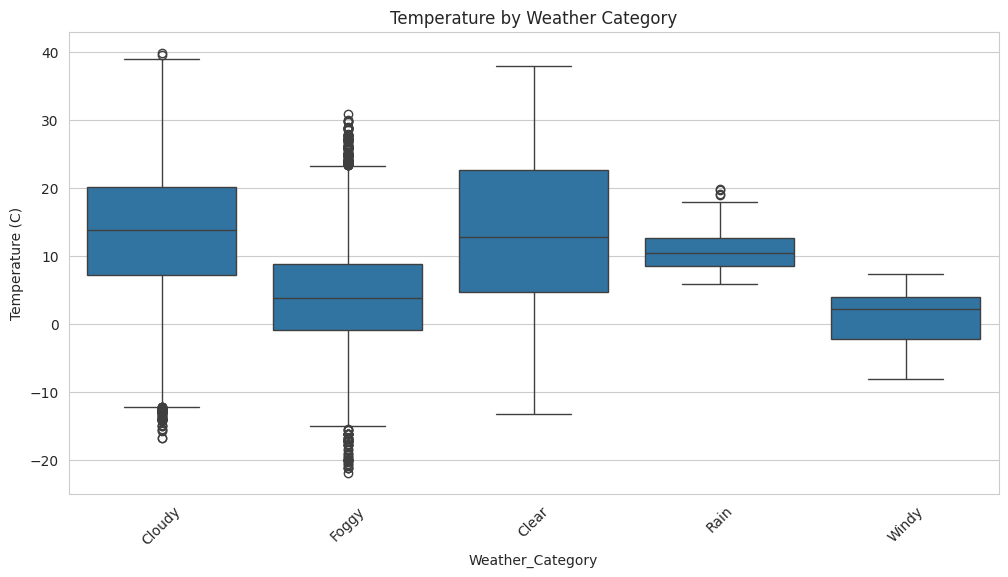

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Weather_Category',y='Temperature (C)',data=df)
plt.title('Temperature by Weather Category')
plt.xticks(rotation=45)
plt.show()

Temperature distributions differ across weather categories, with Clear and Cloudy weather showing higher temperatures than Foggy and Windy conditions.

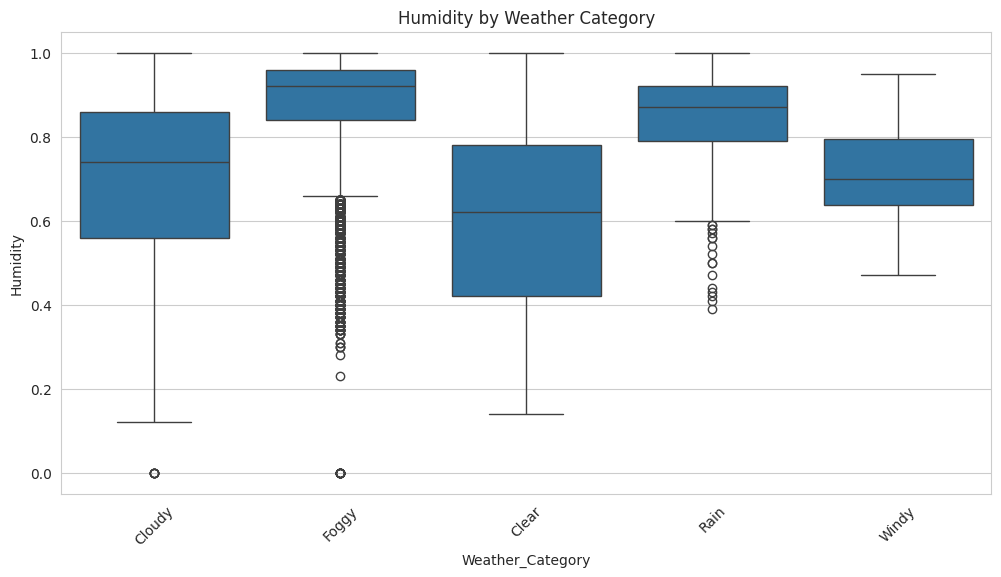

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Weather_Category',y='Humidity',data=df)
plt.title('Humidity by Weather Category')
plt.xticks(rotation=45)
plt.show()

Humidity levels vary across weather categories, with Foggy and Rainy conditions showing higher humidity than Clear weather.

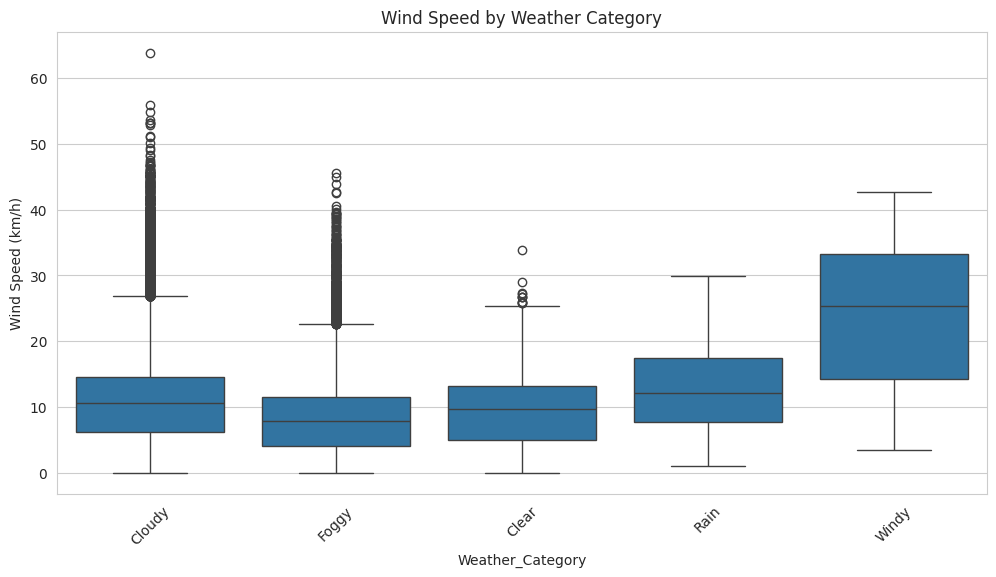

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Weather_Category',y='Wind Speed (km/h)',data=df)
plt.title('Wind Speed by Weather Category')
plt.xticks(rotation=45)
plt.show()

Windy conditions exhibit significantly higher wind speeds compared to other weather categories.

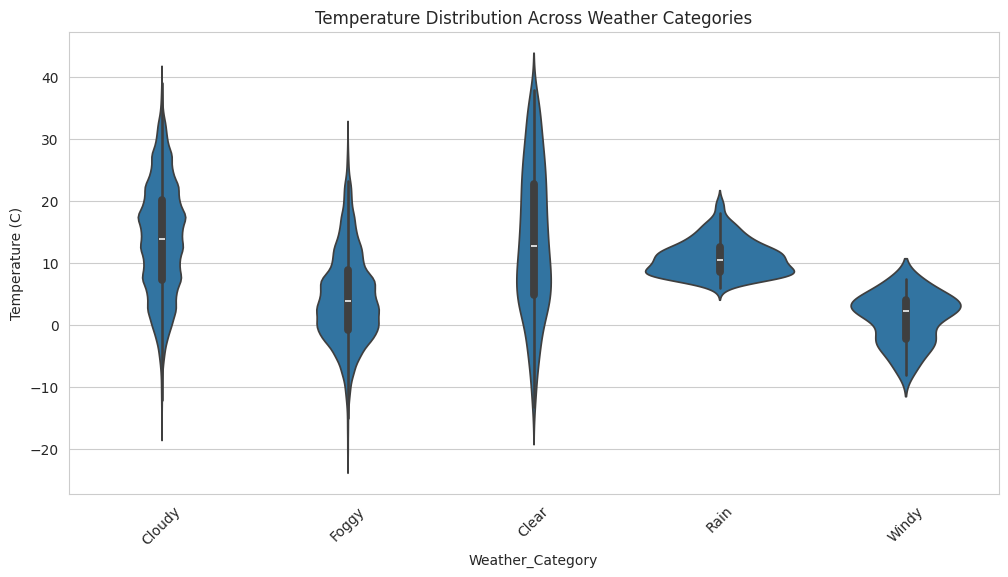

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Weather_Category',y='Temperature (C)',data=df)
plt.title('Temperature Distribution Across Weather Categories')
plt.xticks(rotation=45)
plt.show()

Temperature distributions vary across weather categories, with Clear and Cloudy weather showing greater variability.

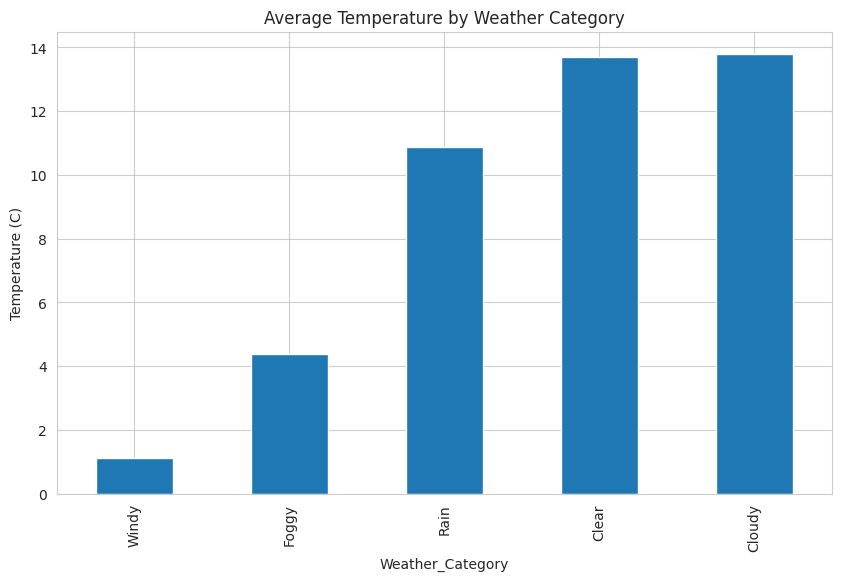

In [ ]:
avg_temp = df.groupby('Weather_Category')['Temperature (C)'].mean().sort_values()
plt.figure(figsize=(10,6))
avg_temp.plot(kind='bar')
plt.title('Average Temperature by Weather Category')
plt.ylabel('Temperature (C)')
plt.show()

Average temperature varies across weather categories, with Cloudy and Clear conditions showing higher temperatures.

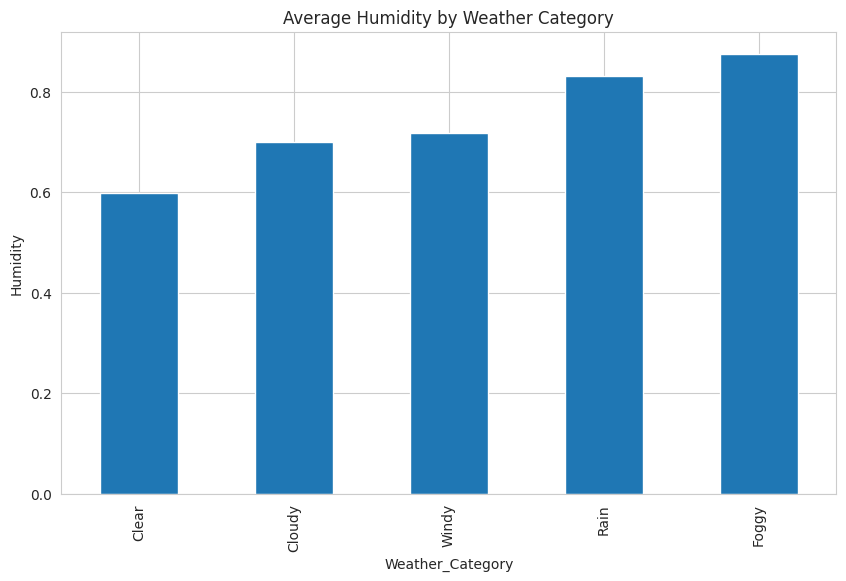

In [ ]:
avg_humidity = df.groupby('Weather_Category')['Humidity'].mean().sort_values()
plt.figure(figsize=(10,6))
avg_humidity.plot(kind='bar')
plt.title('Average Humidity by Weather Category')
plt.ylabel('Humidity')
plt.show()

Average humidity varies across weather categories, with Foggy and Rainy conditions exhibiting higher humidity levels.

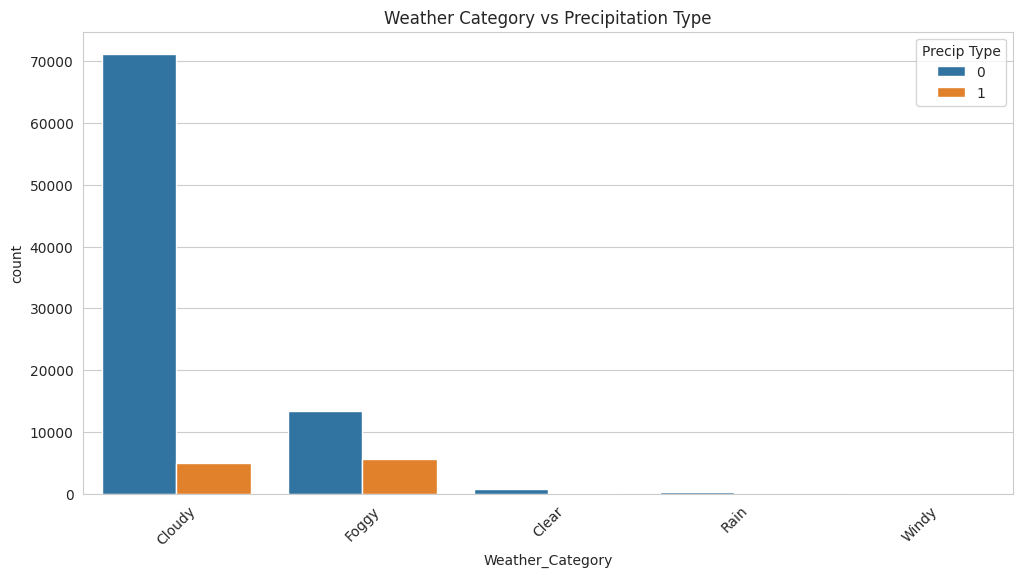

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Weather_Category',hue='Precip Type',data=df)
plt.title('Weather Category vs Precipitation Type')
plt.xticks(rotation=45)
plt.show()

Most weather categories are associated with rain precipitation, while snow occurs less frequently.

# train-Test split after grouping


In [ ]:
x= df.drop(['Daily Summary','Weather_Category'],axis=1)

In [ ]:
target_encoder = LabelEncoder()
y=target_encoder.fit_transform(df['Weather_Category'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Evaluation function

In [ ]:
def evaluate_model(model_name, y_test, y_pred, class_names):

    print("="*60)
    print(model_name)
    print("="*60)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test,y_pred,average='weighted')
    recall = recall_score(y_test,y_pred,average='weighted')
    f1 = f1_score(y_test,y_pred,average='weighted')
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_test,y_pred,target_names=class_names)
    )

  #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {'Accuracy': accuracy,'Precision': precision,'Recall': recall,'F1 Score': f1}

In [ ]:
class_names = target_encoder.classes_

print(class_names)

['Clear' 'Cloudy' 'Foggy' 'Rain' 'Windy']


# Logistic regression after grouping

In [ ]:
lr=LogisticRegression(max_iter=2000,random_state=42)

In [ ]:
lr.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
y_pred_lr=lr.predict(x_test_scaled)

Logistic Regression
Accuracy  : 0.8689
Precision : 0.8561
Recall    : 0.8689
F1 Score  : 0.8587

Classification Report

              precision    recall  f1-score   support

       Clear       0.36      0.05      0.09       183
      Cloudy       0.89      0.95      0.92     15234
       Foggy       0.75      0.59      0.66      3807
        Rain       0.00      0.00      0.00        48
       Windy       0.33      0.14      0.20        14

    accuracy                           0.87     19286
   macro avg       0.47      0.35      0.37     19286
weighted avg       0.86      0.87      0.86     19286



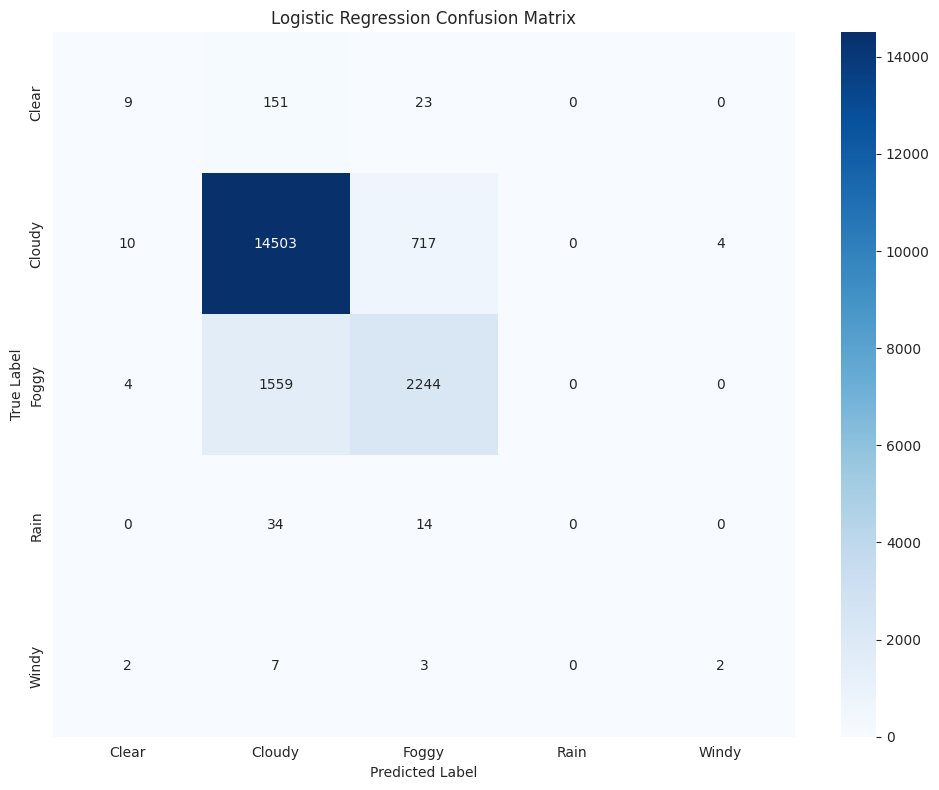

In [ ]:
lr_results = evaluate_model("Logistic Regression",y_test,y_pred_lr,class_names)

# SVM after grouping

In [ ]:
svm = LinearSVC(C=1.0,random_state=42,max_iter=5000)

In [ ]:
svm.fit(x_train_scaled, y_train)
y_pred_svm = svm.predict(x_test_scaled)

Linear SVM
Accuracy  : 0.8696
Precision : 0.8521
Recall    : 0.8696
F1 Score  : 0.8577

Classification Report

              precision    recall  f1-score   support

       Clear       0.00      0.00      0.00       183
      Cloudy       0.89      0.96      0.92     15234
       Foggy       0.76      0.58      0.66      3807
        Rain       0.00      0.00      0.00        48
       Windy       0.00      0.00      0.00        14

    accuracy                           0.87     19286
   macro avg       0.33      0.31      0.32     19286
weighted avg       0.85      0.87      0.86     19286



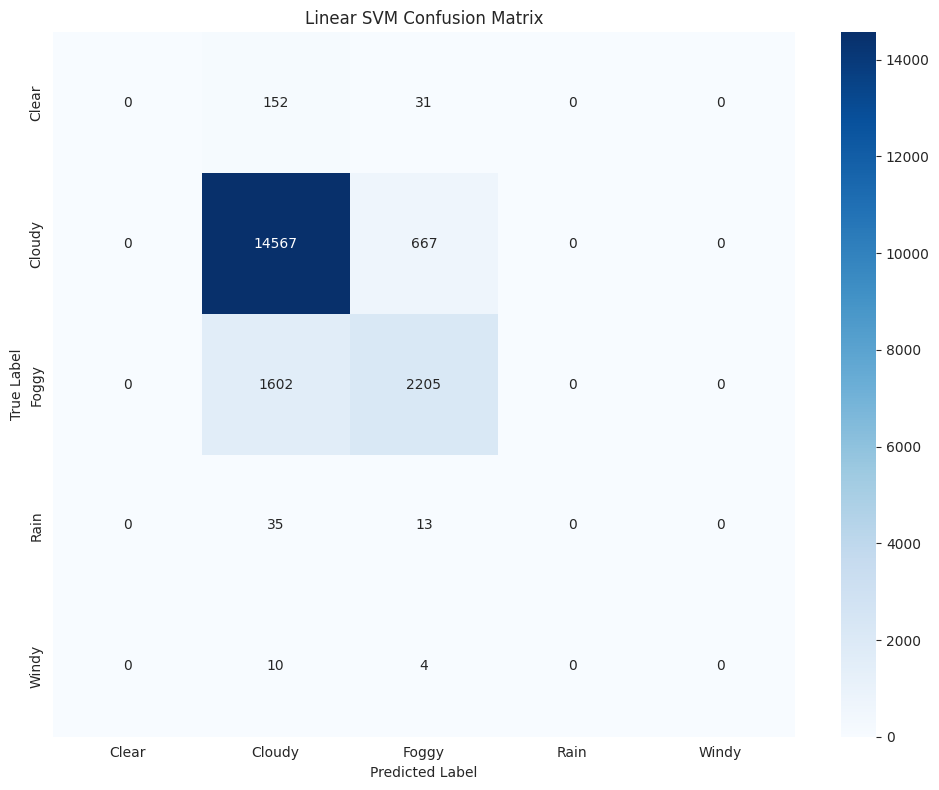

In [ ]:
svm_results = evaluate_model("Linear SVM",y_test,y_pred_svm,class_names)

# Random forest after grouping

In [ ]:
rf = RandomForestClassifier(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)

In [ ]:
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

Random Forest
Accuracy  : 0.9152
Precision : 0.9144
Recall    : 0.9152
F1 Score  : 0.9091

Classification Report

              precision    recall  f1-score   support

       Clear       0.93      0.23      0.37       183
      Cloudy       0.92      0.98      0.95     15234
       Foggy       0.90      0.69      0.78      3807
        Rain       1.00      0.42      0.59        48
       Windy       0.83      0.36      0.50        14

    accuracy                           0.92     19286
   macro avg       0.92      0.54      0.64     19286
weighted avg       0.91      0.92      0.91     19286



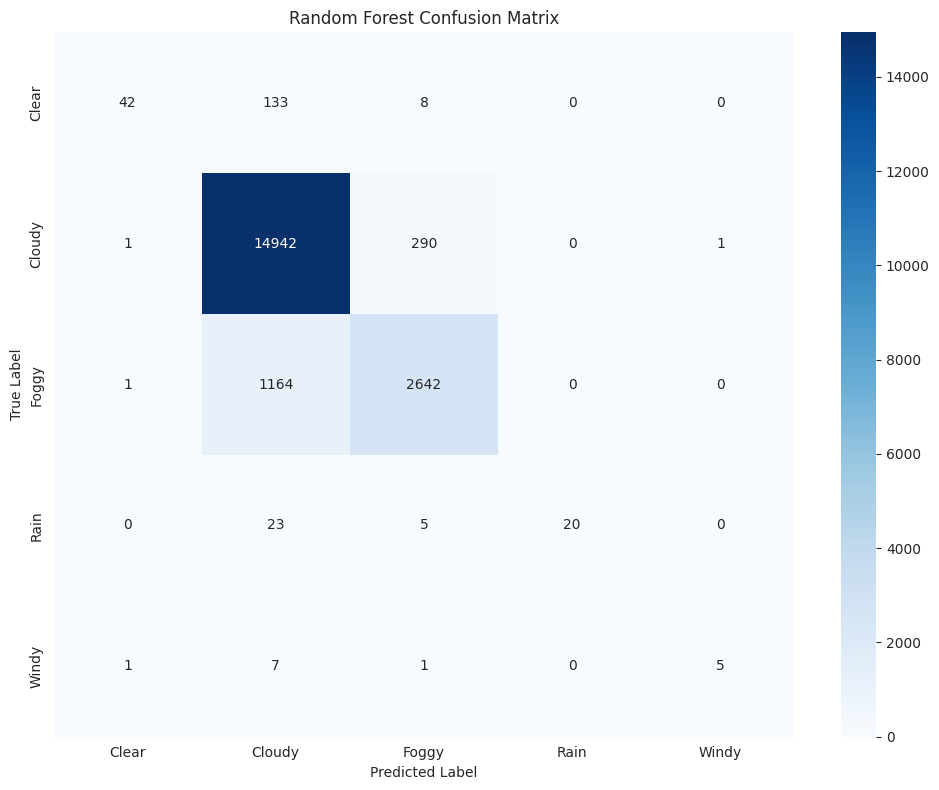

In [ ]:
rf_results = evaluate_model("Random Forest",y_test,y_pred_rf,class_names)

# XGBoost after grouping

In [ ]:
xgb = XGBClassifier(objective='multi:softmax',num_class=len(class_names),n_estimators=200,max_depth=8,learning_rate=0.1,random_state=42,eval_metric='mlogloss')

In [ ]:
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

XGBoost
Accuracy  : 0.9539
Precision : 0.9533
Recall    : 0.9539
F1 Score  : 0.9528

Classification Report

              precision    recall  f1-score   support

       Clear       0.93      0.77      0.84       183
      Cloudy       0.96      0.99      0.97     15234
       Foggy       0.94      0.84      0.88      3807
        Rain       0.93      0.85      0.89        48
       Windy       0.90      0.64      0.75        14

    accuracy                           0.95     19286
   macro avg       0.93      0.82      0.87     19286
weighted avg       0.95      0.95      0.95     19286



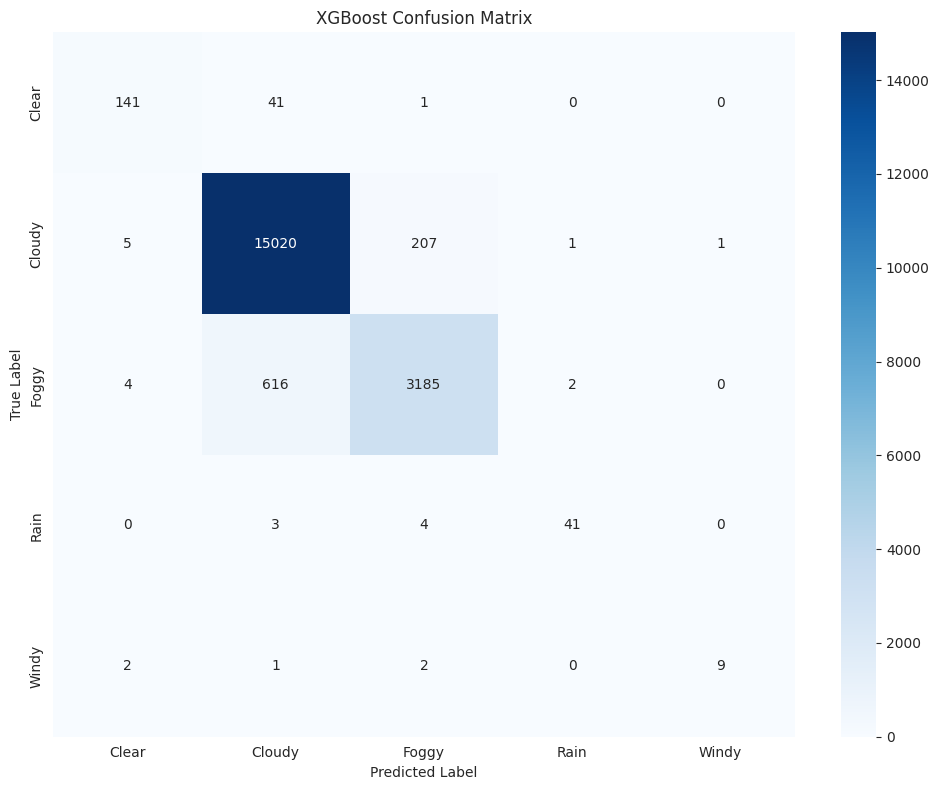

In [ ]:
xgb_results = evaluate_model("XGBoost",y_test,y_pred_xgb,class_names)

# Model comparison

In [ ]:
comparison = pd.DataFrame([{'Model':'Logistic Regression', **lr_results},{'Model':'SVM', **svm_results},{'Model':'Random Forest', **rf_results},{'Model':'XGBoost', **xgb_results}])
comparison = comparison.round(4)
comparison.sort_values(by='F1 Score',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.9539,0.9533,0.9539,0.9528
2,Random Forest,0.9152,0.9144,0.9152,0.9091
0,Logistic Regression,0.8689,0.8561,0.8689,0.8587
1,SVM,0.8696,0.8521,0.8696,0.8577


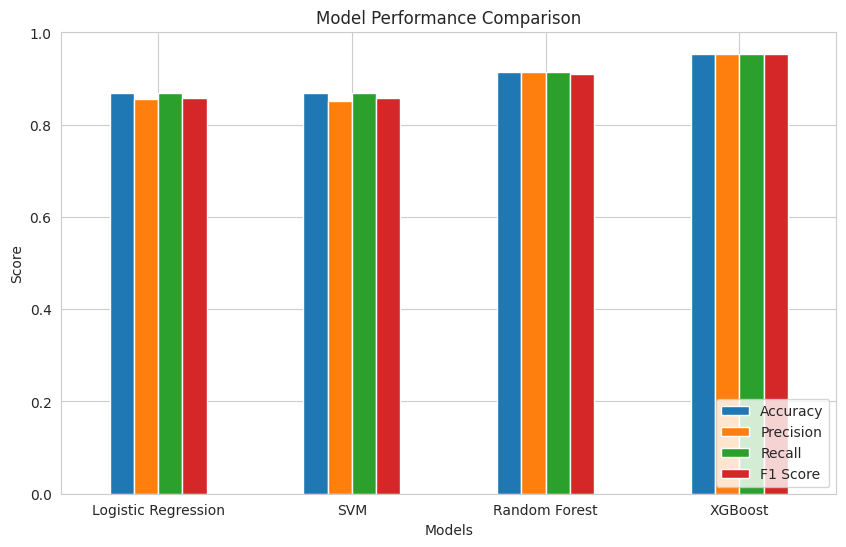

In [ ]:
comparison.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar',figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Feature importance

In [ ]:
importance = pd.DataFrame({'Feature': x.columns,'Importance': xgb.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
print(importance)

                     Feature  Importance
7            Visibility (km)    0.420262
0                    Summary    0.109751
10                     Month    0.071729
9                       Year    0.047140
14             Humidity_Temp    0.041476
12                      Hour    0.039527
11                       Day    0.038562
8       Pressure (millibars)    0.033368
4                   Humidity    0.030583
3   Apparent Temperature (C)    0.029186
2            Temperature (C)    0.028122
13                 Temp_Diff    0.025221
5          Wind Speed (km/h)    0.022222
15           Wind_Visibility    0.021756
6     Wind Bearing (degrees)    0.021549
1                Precip Type    0.019545


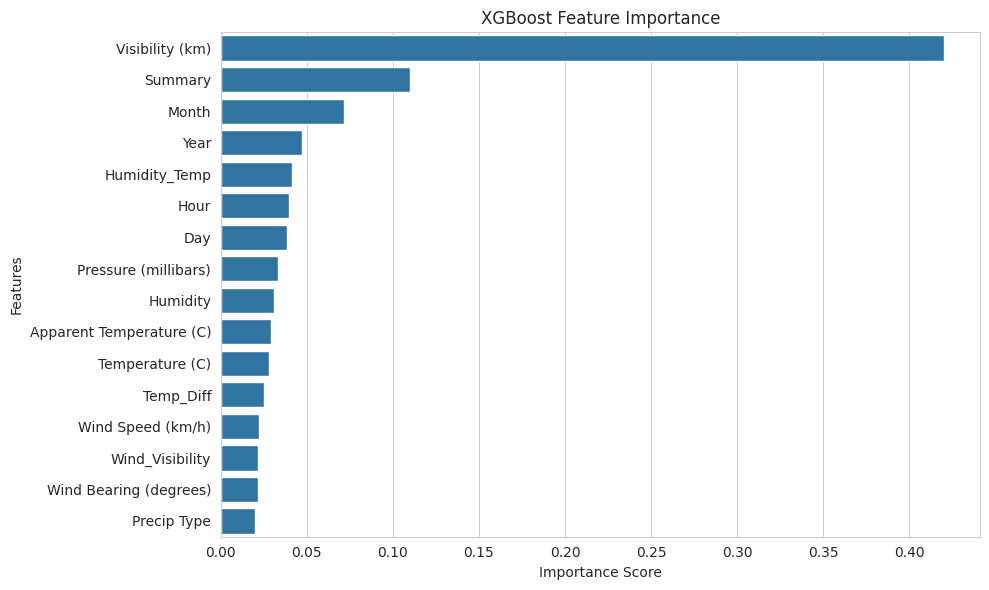

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Conclusion

This project successfully developed a machine learning-based weather classification system using historical weather data. The dataset was cleaned and preprocessed through missing value handling, duplicate removal, feature extraction, and weather category creation from the Daily Summary column. Exploratory Data Analysis (EDA) was performed to understand feature distributions, identify class imbalance, and analyze relationships among weather attributes. To simplify the classification problem and improve model performance, similar weather descriptions were grouped into broader weather categories such as Cloudy, Foggy, Rain, Windy, Clear, and Other. Four machine learning models—Logistic Regression, SVM, Random Forest, and XGBoost—were trained and evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix. Among all models, XGBoost achieved the best overall performance, demonstrating its ability to effectively capture complex patterns in weather data. Feature importance analysis further showed that temperature, humidity, visibility, and wind-related attributes play a significant role in weather classification. Overall, the project highlights the effectiveness of machine learning techniques for weather prediction and provides a strong foundation for future improvements using advanced feature engineering and more balanced weather categories.